<a href="https://colab.research.google.com/github/Luppouk/Atividades-Calculo-Numerico/blob/main/atividade3/cn_atividade_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade prática III - Bisseção, Newton e Secante

## Parte 1: Implementação dos métodos

Os três métodos estão implementados em funções independentes:

- `bissecao(f, a, b, tol, max_iter)`
- `newton(f, df, x0, tol, max_iter)`
- `secante(f, x0, x1, tol, max_iter)`

Todas devolvem um dicionário com o mesmo formato:

| Chave | Conteúdo |
|---|---|
| `raiz` | aproximação final (`None` se o método não pôde começar) |
| `iteracoes` | número de aproximações calculadas |
| `aproximacoes` | lista com a aproximação produzida em cada iteração |
| `convergiu` | `True` se convergiu, `False` se falhou |
| `mensagem` | motivo da parada |
| `historico` | DataFrame com os dados de cada passo (usado nas animações da Parte 3) |
| `metodo`, `valores_iniciais` | identificação da execução |

A tolerância e o número máximo de iterações ficam nas constantes `TOL` e `MAX_ITER`, definidas na próxima célula.

In [19]:
import math
import numpy as np
import pandas as pd
from IPython.display import display

# Parâmetros globais
TOL = 1e-6        # tolerância
MAX_ITER = 100    # número máximo de iterações

# Função para padronizar o resultado dos métodos para montar a tabela
def montar_resultado(metodo, raiz, aproximacoes, convergiu, mensagem, historico, valores_iniciais):
    """Formato de saída comum aos três métodos."""
    return {
        "metodo": metodo,                      # nome do método
        "valores_iniciais": valores_iniciais,  # texto com intervalo ou chutes iniciais
        "raiz": raiz,                          # aproximação final (None se não houver)
        "iteracoes": len(aproximacoes),        # número de aproximações calculadas
        "aproximacoes": list(aproximacoes),    # aproximação produzida em cada iteração
        "convergiu": convergiu,                # True = convergiu, False = falha
        "mensagem": mensagem,                  # motivo da parada
        "historico": pd.DataFrame(historico),  # dados de cada passo (usados na Parte 3)
    }

In [20]:
def bissecao(f, a, b, tol=TOL, max_iter=MAX_ITER):
    """Método da bisseção no intervalo [a, b]."""
    iniciais = f"[{a:g}, {b:g}]"
    aproximacoes, historico = [], []
    a, b = float(a), float(b)

    # Verificações antes de iterar
    if a >= b:
        return montar_resultado("Bisseção", None, aproximacoes, False,
                                "falha: é preciso ter a < b", historico, iniciais)
    fa, fb = f(a), f(b)
    if not (math.isfinite(fa) and math.isfinite(fb)):
        return montar_resultado("Bisseção", None, aproximacoes, False,
                                "falha: f não é finita nas extremidades", historico, iniciais)
    if fa == 0:
        return montar_resultado("Bisseção", a, aproximacoes, True,
                                "a já é raiz", historico, iniciais)
    if fb == 0:
        return montar_resultado("Bisseção", b, aproximacoes, True,
                                "b já é raiz", historico, iniciais)
    if fa * fb > 0:
        return montar_resultado("Bisseção", None, aproximacoes, False,
                                "falha: f(a)f(b) > 0 (sem mudança de sinal)", historico, iniciais)

    for k in range(1, max_iter + 1):
        m = a + (b - a) / 2      # ponto médio (forma que evita overflow em a + b)
        fm = f(m)
        erro = (b - a) / 2       # cota do erro: |raiz − m| ≤ (b − a)/2
        aproximacoes.append(m)
        historico.append({"k": k, "a": a, "b": b, "m": m,
                          "f(a)": fa, "f(m)": fm, "f(b)": fb, "erro máximo": erro})

        if fm == 0:
            return montar_resultado("Bisseção", m, aproximacoes, True,
                                    "convergiu: raiz exata", historico, iniciais)
        if erro <= tol:
            return montar_resultado("Bisseção", m, aproximacoes, True,
                                    "convergiu: (b−a)/2 ≤ tol", historico, iniciais)

        # Mantém a metade em que a mudança de sinal continua
        if fa * fm < 0:
            b, fb = m, fm
        else:
            a, fa = m, fm

    return montar_resultado("Bisseção", m, aproximacoes, False,
                            "falha: atingiu max_iter", historico, iniciais)

In [21]:
def newton(f, df, x0, tol=TOL, max_iter=MAX_ITER, deriv_tol=1e-14):
    """Método de Newton a partir de x0; df é a derivada de f."""
    iniciais = f"x0 = {x0:g}"
    aproximacoes, historico = [], []
    x = float(x0)
    fx = f(x)

    if abs(fx) <= tol:
        return montar_resultado("Newton", x, aproximacoes, True,
                                "x0 já satisfaz |f(x0)| ≤ tol", historico, iniciais)

    for k in range(1, max_iter + 1):
        dfx = df(x)
        if abs(dfx) <= deriv_tol:
            return montar_resultado("Newton", x, aproximacoes, False,
                                    "falha: f'(x_k) nula ou muito pequena", historico, iniciais)

        x_novo = x - fx / dfx    # passo de Newton
        if not math.isfinite(x_novo):
            return montar_resultado("Newton", x, aproximacoes, False,
                                    "falha: valor não finito (divergência)", historico, iniciais)

        f_novo = f(x_novo)
        passo = abs(x_novo - x)
        aproximacoes.append(x_novo)
        historico.append({"k": k, "x_k": x, "f(x_k)": fx, "f'(x_k)": dfx,
                          "x_k+1": x_novo, "f(x_k+1)": f_novo, "passo": passo})
        x, fx = x_novo, f_novo

        # Critério principal: resíduo
        if abs(fx) <= tol:
            return montar_resultado("Newton", x, aproximacoes, True,
                                    "convergiu: |f(x)| ≤ tol", historico, iniciais)
        # Estagnação: x parou de mudar, mas f(x) não chegou perto de zero
        if passo <= tol * max(1.0, abs(x)):
            return montar_resultado("Newton", x, aproximacoes, False,
                                    "falha: passo pequeno, mas resíduo alto", historico, iniciais)

    return montar_resultado("Newton", x, aproximacoes, False,
                            "falha: atingiu max_iter", historico, iniciais)

In [22]:
def secante(f, x0, x1, tol=TOL, max_iter=MAX_ITER, denom_tol=1e-14):
    """Método da secante a partir de x0 e x1."""
    iniciais = f"(x0, x1) = ({x0:g}, {x1:g})"
    aproximacoes, historico = [], []
    x_ant, x_at = float(x0), float(x1)
    f_ant, f_at = f(x_ant), f(x_at)

    if abs(f_at) <= tol:
        return montar_resultado("Secante", x_at, aproximacoes, True,
                                "x1 já satisfaz |f(x1)| ≤ tol", historico, iniciais)

    for k in range(1, max_iter + 1):
        denominador = f_at - f_ant
        if abs(denominador) <= denom_tol:
            return montar_resultado("Secante", x_at, aproximacoes, False,
                                    "falha: denominador nulo ou muito pequeno", historico, iniciais)

        x_novo = x_at - f_at * (x_at - x_ant) / denominador   # passo da secante
        if not math.isfinite(x_novo):
            return montar_resultado("Secante", x_at, aproximacoes, False,
                                    "falha: valor não finito (divergência)", historico, iniciais)

        f_novo = f(x_novo)       # única avaliação nova de f por iteração
        passo = abs(x_novo - x_at)
        aproximacoes.append(x_novo)
        historico.append({"k": k, "x_k-1": x_ant, "x_k": x_at, "f(x_k-1)": f_ant, "f(x_k)": f_at,
                          "x_k+1": x_novo, "f(x_k+1)": f_novo, "passo": passo})
        x_ant, f_ant, x_at, f_at = x_at, f_at, x_novo, f_novo

        if abs(f_at) <= tol:
            return montar_resultado("Secante", x_at, aproximacoes, True,
                                    "convergiu: |f(x)| ≤ tol", historico, iniciais)
        if passo <= tol * max(1.0, abs(x_at)):
            return montar_resultado("Secante", x_at, aproximacoes, False,
                                    "falha: passo pequeno, mas resíduo alto", historico, iniciais)

    return montar_resultado("Secante", x_at, aproximacoes, False,
                            "falha: atingiu max_iter", historico, iniciais)

### Critério de parada adotado

Usamos $\text{tol} = 10^{-6}$ e no máximo 100 iterações.

**Bisseção.** O método para quando a meia largura do intervalo satisfaz

$$\frac{b_k - a_k}{2} \le \text{tol},$$

ou quando $f(m_k) = 0$. Como a raiz está em $[a_k, b_k]$ e $m_k$ é o ponto médio, isso garante $|x^* - m_k| \le \text{tol}$. É um critério sobre o erro em $x$, não sobre o resíduo; por isso $|f(m_k)|$ final pode ficar um pouco acima de tol.

**Newton e secante.** O critério principal é o resíduo,

$$|f(x_{k+1})| \le \text{tol}.$$

A diferença entre aproximações sucessivas funciona como teste de estagnação: se

$$|x_{k+1} - x_k| \le \text{tol}\cdot\max(1, |x_{k+1}|)$$

mas o resíduo ainda está acima de tol, o método para e a execução é marcada como falha, pois as aproximações pararam de mudar sem que $f$ se aproximasse de zero (o que pode acontecer, por exemplo, perto de uma raiz múltipla). O fator $\max(1, |x|)$ deixa o teste absoluto quando $|x| \le 1$ e relativo para valores maiores.

**Situações de falha detectadas**

- bisseção: $a \ge b$, $f$ não finita nas extremidades ou $f(a)f(b) > 0$;
- Newton: $|f'(x_k)| \le 10^{-14}$;
- secante: $|f(x_k) - f(x_{k-1})| \le 10^{-14}$;
- Newton e secante: aproximação não finita (divergência) ou passo pequeno com resíduo alto;
- todos: `max_iter` atingido sem convergência.

**Contagem de iterações.** `iteracoes` é o número de novas aproximações calculadas: pontos médios na bisseção e valores $x_{k+1}$ em Newton e secante. Se o valor inicial já satisfaz o critério, o resultado tem 0 iterações.

## Parte 2 — Aplicação e análise

Os testes usam os valores sugeridos no enunciado. Em todos os intervalos da bisseção há mudança de sinal ($f(a)f(b) < 0$), e os valores iniciais de Newton e da secante estão dentro desses intervalos ou em suas extremidades.

Para alterar uma função, a derivada ou os valores iniciais, basta editar a lista `casos` abaixo. A tolerância e o limite de iterações podem ser mudados em `TOL` e `MAX_ITER`, ou passados diretamente para `executar_casos(casos, tol=..., max_iter=...)`.

In [23]:
# Cada caso: nome, função, derivada e valores iniciais de cada método.
# Para testar outra função ou outros valores, edite ou acrescente um dicionário.
# Um método pode ser omitido retirando sua chave ("bissecao", "newton" ou "secante").
casos = [
    {"nome": "f1(x) = x² − 2",
     "f":  lambda x: x**2 - 2,
     "df": lambda x: 2*x,
     "bissecao": (1, 2), "newton": 1.5, "secante": (1, 2)},

    {"nome": "f2(x) = x³ − x − 2",
     "f":  lambda x: x**3 - x - 2,
     "df": lambda x: 3*x**2 - 1,
     "bissecao": (1, 2), "newton": 1.5, "secante": (1, 2)},

    {"nome": "f3(x) = e^(−x) − x",
     "f":  lambda x: np.exp(-x) - x,
     "df": lambda x: -np.exp(-x) - 1,
     "bissecao": (0, 1), "newton": 0.5, "secante": (0, 1)},

    {"nome": "f4(x) = x³ − 2x + 2",
     "f":  lambda x: x**3 - 2*x + 2,
     "df": lambda x: 3*x**2 - 2,
     "bissecao": (-2, -1), "newton": -2, "secante": (-2, -1)},
]

In [24]:
def executar_casos(casos, tol=TOL, max_iter=MAX_ITER):
    """Roda os métodos definidos em cada caso e monta a tabela de resultados."""
    resultados, linhas = [], []
    for caso in casos:
        f = caso["f"]
        execucoes = []
        if "bissecao" in caso:
            a, b = caso["bissecao"]
            execucoes.append(bissecao(f, a, b, tol, max_iter))
        if "newton" in caso:
            execucoes.append(newton(f, caso["df"], caso["newton"], tol, max_iter))
        if "secante" in caso:
            x0, x1 = caso["secante"]
            execucoes.append(secante(f, x0, x1, tol, max_iter))

        for r in execucoes:
            r["funcao"] = caso["nome"]
            resultados.append(r)
            raiz = r["raiz"]
            linhas.append({
                "Função": caso["nome"],
                "Método": r["metodo"],
                "Valores iniciais": r["valores_iniciais"],
                "Raiz aproximada": raiz,
                "|f(x)| final": abs(f(raiz)) if raiz is not None else None,
                "Iterações/resultado": f"{r['iteracoes']} it. — {r['mensagem']}",
            })
    return resultados, pd.DataFrame(linhas)


def formatar_tabela(tabela):
    """Cópia da tabela com os números formatados, apenas para exibição."""
    t = tabela.copy()
    t["Raiz aproximada"] = t["Raiz aproximada"].map(lambda v: "—" if pd.isna(v) else f"{v:.10f}")
    t["|f(x)| final"] = t["|f(x)| final"].map(lambda v: "—" if pd.isna(v) else f"{v:.2e}")
    return t


resultados, tabela = executar_casos(casos)
display(formatar_tabela(tabela))

,Função,Método,Valores iniciais,Raiz aproximada,|f(x)| final,Iterações/resultado
0,f1(x) = x² − 2,Bisseção,"[1, 2]",1.4142141342,1.62e-06,20 it. — convergiu: (b−a)/2 ≤ tol
1,f1(x) = x² − 2,Newton,x0 = 1.5,1.4142135624,4.51e-12,3 it. — convergiu: |f(x)| ≤ tol
2,f1(x) = x² − 2,Secante,"(x0, x1) = (1, 2)",1.4142135621,8.93e-10,5 it. — convergiu: |f(x)| ≤ tol
3,f2(x) = x³ − x − 2,Bisseção,"[1, 2]",1.5213804245,4.27e-06,20 it. — convergiu: (b−a)/2 ≤ tol
4,f2(x) = x³ − x − 2,Newton,x0 = 1.5,1.5213798060,5.89e-07,2 it. — convergiu: |f(x)| ≤ tol
5,f2(x) = x³ − x − 2,Secante,"(x0, x1) = (1, 2)",1.5213797080,7.02e-09,6 it. — convergiu: |f(x)| ≤ tol
6,f3(x) = e^(−x) − x,Bisseção,"[0, 1]",0.5671434402,2.35e-07,20 it. — convergiu: (b−a)/2 ≤ tol
7,f3(x) = e^(−x) − x,Newton,x0 = 0.5,0.5671431650,1.96e-07,2 it. — convergiu: |f(x)| ≤ tol
8,f3(x) = e^(−x) − x,Secante,"(x0, x1) = (0, 1)",0.5671433066,2.54e-08,4 it. — convergiu: |f(x)| ≤ tol
9,f4(x) = x³ − 2x + 2,Bisseção,"[-2, -1]",-1.7692918777,3.52e-06,20 it. — convergiu: (b−a)/2 ≤ tol


In [25]:
# Erro real de cada aproximação: comparamos com uma raiz de referência
# calculada pelo método de Brent (scipy) com tolerância de 1e-15.
from scipy.optimize import brentq

linhas = []
for caso in casos:
    a, b = caso["bissecao"]
    x_ref = brentq(caso["f"], a, b, xtol=1e-15)   # raiz de referência
    for r in resultados:
        if r["funcao"] == caso["nome"] and r["raiz"] is not None:
            linhas.append({"Função": caso["nome"], "Método": r["metodo"],
                           "Raiz de referência": f"{x_ref:.12f}",
                           "|x − x_ref|": f"{abs(r['raiz'] - x_ref):.2e}"})
display(pd.DataFrame(linhas))

,Função,Método,Raiz de referência,|x − x_ref|
0,f1(x) = x² − 2,Bisseção,1.414213562373,5.72e-07
1,f1(x) = x² − 2,Newton,1.414213562373,1.59e-12
2,f1(x) = x² − 2,Secante,1.414213562373,3.16e-10
3,f2(x) = x³ − x − 2,Bisseção,1.521379706805,7.18e-07
4,f2(x) = x³ − x − 2,Newton,1.521379706805,9.92e-08
5,f2(x) = x³ − x − 2,Secante,1.521379706805,1.18e-09
6,f3(x) = e^(−x) − x,Bisseção,0.567143290410,1.50e-07
7,f3(x) = e^(−x) − x,Newton,0.567143290410,1.25e-07
8,f3(x) = e^(−x) − x,Secante,0.567143290410,1.62e-08
9,f4(x) = x³ − 2x + 2,Bisseção,-1.769292354239,4.76e-07


### Testes de falha

Para verificar se as falhas pedidas na Parte 1 são detectadas, repetimos os métodos com valores iniciais escolhidos para dar errado:

- **Newton em $f_4$ com $x_0 = 0$:** $f_4(0) = 2$ e $f_4'(0) = -2$ levam a $x_1 = 1$; depois $f_4(1) = 1$ e $f_4'(1) = 1$ levam de volta a $x_2 = 0$. O método entra em um ciclo e esgota as iterações.
- **Bisseção em $f_1$ com $[-1, 1]$:** $f_1(-1) = f_1(1) = -1$, sem mudança de sinal (e de fato não há raiz nesse intervalo).
- **Newton em $f_1$ com $x_0 = 0$:** $f_1'(0) = 0$, ou seja, a reta tangente é horizontal.
- **Secante em $f_1$ com $(-1, 1)$:** $f_1(-1) = f_1(1)$, então a secante é horizontal e o denominador se anula.

In [26]:
casos_falha = [
    {"nome": "f4(x) = x³ − 2x + 2",
     "f":  lambda x: x**3 - 2*x + 2,
     "df": lambda x: 3*x**2 - 2,
     "newton": 0},

    {"nome": "f1(x) = x² − 2",
     "f":  lambda x: x**2 - 2,
     "df": lambda x: 2*x,
     "bissecao": (-1, 1), "newton": 0, "secante": (-1, 1)},
]

resultados_falha, tabela_falha = executar_casos(casos_falha)
display(formatar_tabela(tabela_falha))

# Primeiras aproximações de Newton em f4 com x0 = 0
print("Newton em f4, x0 = 0:", resultados_falha[0]["aproximacoes"][:8])

,Função,Método,Valores iniciais,Raiz aproximada,|f(x)| final,Iterações/resultado
0,f4(x) = x³ − 2x + 2,Newton,x0 = 0,0.0000000000,2.00e+00,100 it. — falha: atingiu max_iter
1,f1(x) = x² − 2,Bisseção,"[-1, 1]",—,—,0 it. — falha: f(a)f(b) > 0 (sem mudança de si...
2,f1(x) = x² − 2,Newton,x0 = 0,0.0000000000,2.00e+00,0 it. — falha: f'(x_k) nula ou muito pequena
3,f1(x) = x² − 2,Secante,"(x0, x1) = (-1, 1)",1.0000000000,1.00e+00,0 it. — falha: denominador nulo ou muito pequeno


Newton em f4, x0 = 0: [1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0]


### Análise dos resultados

Com os valores sugeridos, os 12 testes convergiram, e as raízes encontradas foram

$$x_1^* \approx 1{,}4142136,\quad x_2^* \approx 1{,}5213797,\quad x_3^* \approx 0{,}5671433,\quad x_4^* \approx -1{,}7692924.$$

**Bisseção.** Foram 20 iterações nas quatro funções. Isso não depende de $f$: como todos os intervalos têm largura 1, o número de passos é fixado pela tolerância,

$$n = \left\lceil \log_2\frac{b_0 - a_0}{\text{tol}} \right\rceil = \lceil \log_2 10^6 \rceil = 20.$$

Em $f_1$, $f_2$ e $f_4$, o resíduo final ficou acima de $10^{-6}$ ($1{,}6\times10^{-6}$, $4{,}3\times10^{-6}$ e $3{,}5\times10^{-6}$), mas o erro em relação à raiz de referência ficou abaixo de $10^{-6}$ em todos os casos, como o critério garante. Resíduo e erro em $x$ são medidas diferentes: perto da raiz, $|f(x)| \approx |f'(x^*)|\,|x - x^*|$, e $|f'(x^*)|$ vale cerca de 2,8 em $f_1$, 5,9 em $f_2$, 1,6 em $f_3$ e 7,4 em $f_4$. Quanto mais inclinada a função na raiz, maior o resíduo para o mesmo erro.

**Newton.** Foi o mais rápido, com 2 a 4 iterações, graças à convergência quadrática: perto da raiz, o número de dígitos corretos aproximadamente dobra a cada passo. Isso aparece nos resíduos. Em $f_1$ e $f_4$, a penúltima iteração ficou pouco acima da tolerância ($6{,}0\times10^{-6}$ e $2{,}3\times10^{-6}$), e o último passo levou o resíduo direto a $10^{-12}$ e $10^{-13}$. Em $f_2$ e $f_3$, o critério foi atingido com resíduos de $5{,}9\times10^{-7}$ e $2{,}0\times10^{-7}$, logo abaixo de tol. O custo é precisar da derivada e avaliar $f$ e $f'$ a cada iteração.

**Secante.** Ficou entre os dois, com 4 a 6 iterações. A convergência é superlinear (ordem $\approx 1{,}618$), mais lenta que a de Newton, mas o método não precisa da derivada e faz só uma avaliação nova de $f$ por iteração.

**Dependência dos valores iniciais.** Os testes de falha mostram que Newton e secante não têm a garantia da bisseção. Em $f_4$, o mesmo método de Newton que converge em 4 iterações a partir de $x_0 = -2$ entra em ciclo a partir de $x_0 = 0$. A bisseção sempre converge quando $f$ é contínua e há mudança de sinal, mas é o mais lento dos três e depende de encontrar um intervalo com essa mudança.

## Parte 3 — Animação gráfica

A função `animar` gera um GIF a partir do dicionário devolvido por qualquer um dos três métodos. Cada quadro corresponde a uma iteração e tem três painéis:

- **Visão geral:** gráfico de $f(x)$, eixo $y = 0$, aproximações anteriores (cinza) e atual (vermelho), além da construção usada no passo: o intervalo $[a_k, b_k]$ na bisseção, a reta tangente em Newton e a reta secante no método da secante. A caixa de texto mostra o número da iteração, a aproximação atual e o resíduo $|f(x_k)|$; na bisseção, também o intervalo e a cota $(b_k - a_k)/2$. O retângulo pontilhado marca a região ampliada no painel de zoom.
- **Zoom na construção atual:** janela que acompanha o passo em andamento. Newton e secante convergem tão rápido que, depois de duas ou três iterações, a construção fica invisível na escala da visão geral; o zoom permite ver as retas mesmo nesses passos.
- **Indicadores de erro:** $|f(x_k)|$ em escala logarítmica, com a linha da tolerância. Na bisseção aparece também $(b_k - a_k)/2$.

O quadro 0 mostra os valores iniciais, e o último quadro fica parado por alguns segundos com o motivo da parada.

Foram animadas quatro combinações: bisseção em $f_2$, Newton em $f_4$, secante em $f_3$ e o caso de falha de Newton em $f_4$ com $x_0 = 0$. Para animar outra combinação, basta acrescentar uma linha à lista `animacoes`.

In [27]:
import os
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator
from IPython.display import Image

PASTA_GIFS = "gifs"                 # pasta onde os GIFs serão salvos
os.makedirs(PASTA_GIFS, exist_ok=True)

# Cores usadas em todas as animações
COR_CURVA = "tab:blue"
COR_CONSTRUCAO = "tab:orange"       # tangentes, secantes, linhas auxiliares
COR_INTERVALO = "tab:green"         # intervalo da bisseção
COR_ATUAL = "tab:red"               # aproximação atual
COR_ANTERIOR = "0.6"                # aproximações anteriores (cinza)


def avaliar(f, xs):
    """Avalia f ponto a ponto (funciona mesmo se f usar math em vez de numpy)."""
    return np.array([f(x) for x in xs], dtype=float)


def limites_y(y, folga=0.12):
    """Limites verticais que incluem y = 0 e uma pequena folga."""
    lo, hi = min(np.nanmin(y), 0.0), max(np.nanmax(y), 0.0)
    d = hi - lo if hi > lo else 1.0
    return lo - folga * d, hi + folga * d


def pontos_da_iteracao(metodo, h, i, iniciais):
    """Abscissas envolvidas na construção da iteração i (i = 0: valores iniciais)."""
    if i == 0:
        return list(iniciais)
    linha = h.iloc[i - 1]
    if metodo == "Bisseção":
        return [linha["a"], linha["b"]]
    if metodo == "Newton":
        return [linha["x_k"], linha["x_k+1"]]
    return [linha["x_k-1"], linha["x_k"], linha["x_k+1"]]      # secante


def janela_zoom(metodo, h, i, iniciais, largura_global):
    """Janela horizontal do painel de zoom, centrada na construção atual."""
    # No quadro inicial de Newton há um só ponto; usamos a janela do 1º passo.
    if i == 0 and metodo == "Newton" and len(h) > 0:
        i = 1
    xs = pontos_da_iteracao(metodo, h, i, iniciais)
    lo, hi = min(xs), max(xs)
    centro = (lo + hi) / 2
    meia = max(0.75 * (hi - lo), 1e-3 * largura_global)   # largura mínima do zoom
    return centro - meia, centro + meia


def desenhar_construcao(ax, metodo, h, i, f, iniciais):
    """Desenha intervalo (bisseção), tangente (Newton) ou secante da iteração i."""
    if i == 0:
        if metodo == "Bisseção":
            a, b = iniciais
            ax.axvspan(a, b, color=COR_INTERVALO, alpha=0.15, label="intervalo [a, b]")
            ax.plot([a, b], [f(a), f(b)], "s", color=COR_INTERVALO, ms=6)
        else:
            ax.plot(iniciais, [f(x) for x in iniciais], "s", color=COR_CONSTRUCAO,
                    ms=6, label="valores iniciais")
        return

    linha = h.iloc[i - 1]
    if metodo == "Bisseção":
        a, b, m = linha["a"], linha["b"], linha["m"]
        ax.axvspan(a, b, color=COR_INTERVALO, alpha=0.15, label="intervalo [a, b]")
        ax.plot([a, b], [0, 0], color=COR_INTERVALO, lw=5, solid_capstyle="butt")
        ax.plot([a, b], [linha["f(a)"], linha["f(b)"]], "s", color=COR_INTERVALO, ms=6)
        ax.vlines(m, 0, linha["f(m)"], color=COR_CONSTRUCAO, ls="--", lw=1.2)

    elif metodo == "Newton":
        xk, fk, dfk, xn = linha["x_k"], linha["f(x_k)"], linha["f'(x_k)"], linha["x_k+1"]
        lo, hi = min(xk, xn), max(xk, xn)
        ext = 0.3 * (hi - lo)
        xt = np.array([lo - ext, hi + ext])
        # Reta tangente em (x_k, f(x_k)): y = f(x_k) + f'(x_k)(x − x_k)
        ax.plot(xt, fk + dfk * (xt - xk), color=COR_CONSTRUCAO, lw=1.8, label="reta tangente")
        ax.plot(xk, fk, "o", color=COR_CONSTRUCAO, ms=6)
        ax.vlines(xn, 0, linha["f(x_k+1)"], color=COR_CONSTRUCAO, ls="--", lw=1.2)

    else:  # secante
        x0_, x1_ = linha["x_k-1"], linha["x_k"]
        f0_, f1_ = linha["f(x_k-1)"], linha["f(x_k)"]
        xn = linha["x_k+1"]
        inclinacao = (f1_ - f0_) / (x1_ - x0_)
        lo, hi = min(x0_, x1_, xn), max(x0_, x1_, xn)
        ext = 0.15 * (hi - lo)
        xt = np.array([lo - ext, hi + ext])
        # Reta que passa por (x_{k-1}, f(x_{k-1})) e (x_k, f(x_k))
        ax.plot(xt, f1_ + inclinacao * (xt - x1_), color=COR_CONSTRUCAO, lw=1.8,
                label="reta secante")
        ax.plot([x0_, x1_], [f0_, f1_], "o", color=COR_CONSTRUCAO, ms=6)
        ax.vlines(xn, 0, linha["f(x_k+1)"], color=COR_CONSTRUCAO, ls="--", lw=1.2)


def desenhar_aproximacoes(ax, aprox, i, f):
    """Aproximações anteriores em cinza e a atual em vermelho, sobre o eixo x."""
    anteriores = [x for x in aprox[:i] if x is not None]
    if anteriores:
        ax.plot(anteriores, np.zeros(len(anteriores)), "o", color=COR_ANTERIOR, ms=5,
                label="aproximações anteriores")
    x = aprox[i]
    if x is not None:
        ax.plot(x, 0, "o", color=COR_ATUAL, ms=8, label="aproximação atual", zorder=5)
        ax.plot(x, f(x), "o", mfc="none", mec=COR_ATUAL, ms=8, zorder=5)

In [28]:
def animar(r, f, nome_funcao, arquivo, xlim=None, max_quadros=30, fps=1.5,
           pausa_final=4, tol=TOL):
    """Gera um GIF a partir do resultado r de bissecao, newton ou secante.

    r            dicionário devolvido pelo método
    f            a mesma função usada no método
    nome_funcao  texto para o título
    arquivo      caminho do GIF
    xlim         (xmin, xmax) do painel geral; None = automático
    max_quadros  número máximo de iterações animadas
    fps          quadros por segundo
    pausa_final  quantas vezes o último quadro se repete (pausa no fim)
    """
    metodo = r["metodo"]
    h_completo = r["historico"]
    if h_completo.empty:
        print(f"{metodo} em {nome_funcao}: nada para animar ({r['mensagem']}).")
        return None
    h = h_completo.iloc[:max_quadros]
    n = len(h)

    # Valores iniciais e aproximação de cada iteração (índice = iteração)
    if metodo == "Bisseção":
        iniciais = [h["a"].iloc[0], h["b"].iloc[0]]
        aprox = [None] + list(h["m"])                  # iteração 0 não tem ponto médio
    elif metodo == "Newton":
        iniciais = [h["x_k"].iloc[0]]
        aprox = [h["x_k"].iloc[0]] + list(h["x_k+1"])  # x_0, x_1, x_2, ...
    else:
        iniciais = [h["x_k-1"].iloc[0], h["x_k"].iloc[0]]
        aprox = [h["x_k"].iloc[0]] + list(h["x_k+1"])  # x_1, x_2, x_3, ...
    residuos = [None if x is None else abs(f(x)) for x in aprox]

    # Limites do painel geral (fixos em toda a animação)
    if xlim is None:
        todos = iniciais + [x for x in aprox if x is not None]
        lo, hi = min(todos), max(todos)
        margem = max(0.25 * (hi - lo), 0.25)
        xlim = (lo - margem, hi + margem)
    xg = np.linspace(xlim[0], xlim[1], 600)
    yg = avaliar(f, xg)
    ylim = limites_y(yg)
    largura_global = xlim[1] - xlim[0]

    # Limites do painel de resíduo (escala log; zeros viram 1e-18 para o gráfico)
    valores = [v for v in residuos if v is not None]
    if metodo == "Bisseção":
        valores += list(h["erro máximo"])
    valores = np.maximum(np.array(valores + [tol]), 1e-18)
    ylim_res = (valores.min() / 10, valores.max() * 10)

    fig = plt.figure(figsize=(12, 6.5), dpi=90)
    grade = fig.add_gridspec(2, 2, width_ratios=[1.35, 1], hspace=0.38, wspace=0.22,
                             bottom=0.2, top=0.88)
    ax_geral = fig.add_subplot(grade[:, 0])
    ax_zoom = fig.add_subplot(grade[0, 1])
    ax_res = fig.add_subplot(grade[1, 1])

    def atualizar(i):
        for ax in (ax_geral, ax_zoom, ax_res):
            ax.cla()

        # ---------- painel geral ----------
        ax_geral.plot(xg, yg, color=COR_CURVA, lw=2, label="f(x)")
        ax_geral.axhline(0, color="black", lw=0.9)
        desenhar_construcao(ax_geral, metodo, h, i, f, iniciais)
        desenhar_aproximacoes(ax_geral, aprox, i, f)
        zx = janela_zoom(metodo, h, i, iniciais, largura_global)
        zy = limites_y(avaliar(f, np.linspace(*zx, 200)), folga=0.15)
        ax_geral.add_patch(Rectangle((zx[0], zy[0]), zx[1] - zx[0], zy[1] - zy[0],
                                     fill=False, ls=":", ec="0.3", lw=1))
        ax_geral.set_xlim(xlim)
        ax_geral.set_ylim(ylim)
        ax_geral.set_xlabel("x")
        ax_geral.set_ylabel("f(x)")
        ax_geral.set_title("Visão geral")
        ax_geral.legend(loc="upper center", bbox_to_anchor=(0.5, -0.09), ncol=3, fontsize=8)

        # Caixa de texto: iteração, aproximação atual e resíduo
        texto = [f"Iteração {i}"]
        if aprox[i] is not None:
            texto += [f"x = {aprox[i]:.10f}", f"|f(x)| = {residuos[i]:.2e}"]
        if metodo == "Bisseção":
            a, b = (iniciais if i == 0 else (h["a"].iloc[i - 1], h["b"].iloc[i - 1]))
            texto += [f"[a, b] = [{a:.6f}, {b:.6f}]", f"(b − a)/2 = {(b - a) / 2:.2e}"]
        if i == n:
            if n < len(h_completo):
                texto.append(f"(animação limitada a {n} de {len(h_completo)} iterações)")
            texto.append(r["mensagem"])
        ax_geral.text(0.02, 0.98, "\n".join(texto), transform=ax_geral.transAxes,
                      va="top", ha="left", family="monospace", fontsize=9,
                      bbox=dict(boxstyle="round", fc="white", ec="0.7", alpha=0.9))

        # ---------- painel de zoom ----------
        xz = np.linspace(zx[0], zx[1], 400)
        ax_zoom.plot(xz, avaliar(f, xz), color=COR_CURVA, lw=2)
        ax_zoom.axhline(0, color="black", lw=0.9)
        desenhar_construcao(ax_zoom, metodo, h, i, f, iniciais)
        desenhar_aproximacoes(ax_zoom, aprox, i, f)
        ax_zoom.set_xlim(zx)
        ax_zoom.set_ylim(zy)
        ax_zoom.ticklabel_format(useOffset=False)
        ax_zoom.xaxis.set_major_locator(MaxNLocator(4))
        ax_zoom.yaxis.set_major_locator(MaxNLocator(4))
        ax_zoom.set_title("Zoom na construção atual", fontsize=10)

        # ---------- painel de resíduo ----------
        k0 = 1 if metodo == "Bisseção" else 0
        ks = list(range(k0, i + 1))
        if ks:
            ax_res.semilogy(ks, np.maximum([residuos[k] for k in ks], 1e-18), "o-",
                            color=COR_ATUAL, ms=4, label="|f(x)|")
        if metodo == "Bisseção" and i >= 1:
            ax_res.semilogy(range(1, i + 1), h["erro máximo"].iloc[:i], "s--",
                            color=COR_INTERVALO, ms=3, label="(b − a)/2")
        ax_res.axhline(tol, color="0.4", ls=":", label=f"tol = {tol:g}")
        ax_res.set_xlim(-0.5, n + 0.5)
        ax_res.set_ylim(ylim_res)
        ax_res.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax_res.set_xlabel("iteração")
        ax_res.set_title("Indicadores de erro (escala log)", fontsize=10)
        ax_res.legend(loc="best", fontsize=8)

        fig.suptitle(f"{metodo} — {nome_funcao}", fontsize=13)

    quadros = list(range(n + 1)) + [n] * pausa_final
    anim = FuncAnimation(fig, atualizar, frames=quadros, interval=1000 / fps)
    anim.save(arquivo, writer=PillowWriter(fps=fps))
    plt.close(fig)
    return arquivo

gifs/bissecao_f2.gif: Bisseção, 20 iterações — convergiu: (b−a)/2 ≤ tol


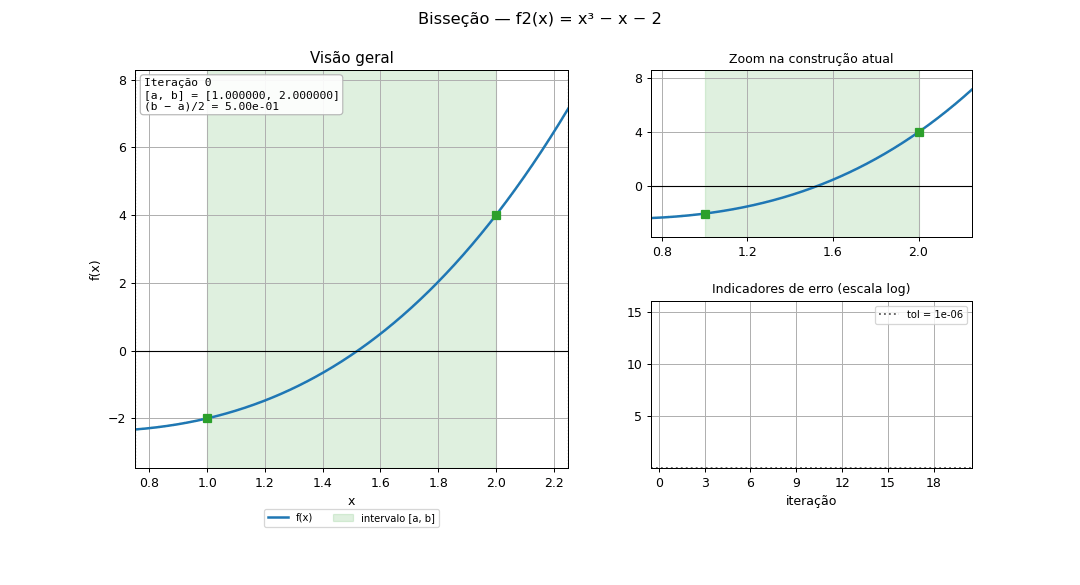

gifs/newton_f4.gif: Newton, 4 iterações — convergiu: |f(x)| ≤ tol


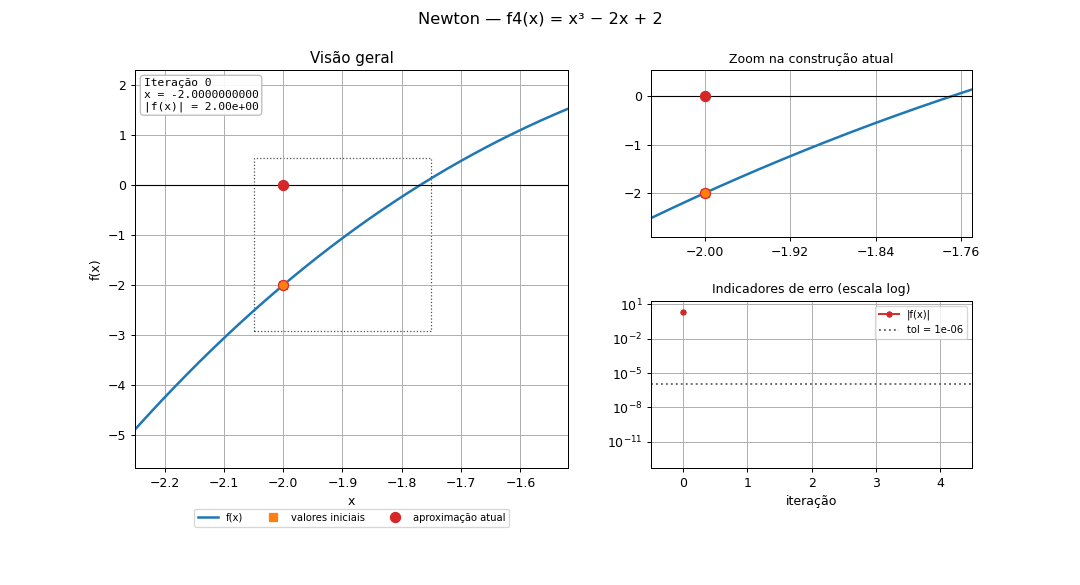

gifs/secante_f3.gif: Secante, 4 iterações — convergiu: |f(x)| ≤ tol


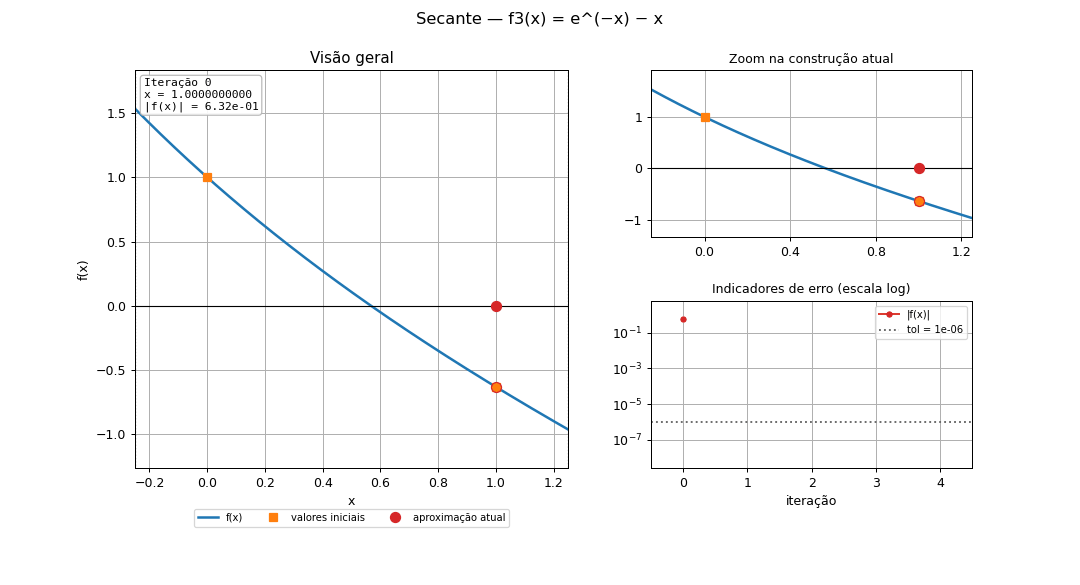

gifs/newton_f4_falha_x0_0.gif: Newton, 100 iterações — falha: atingiu max_iter


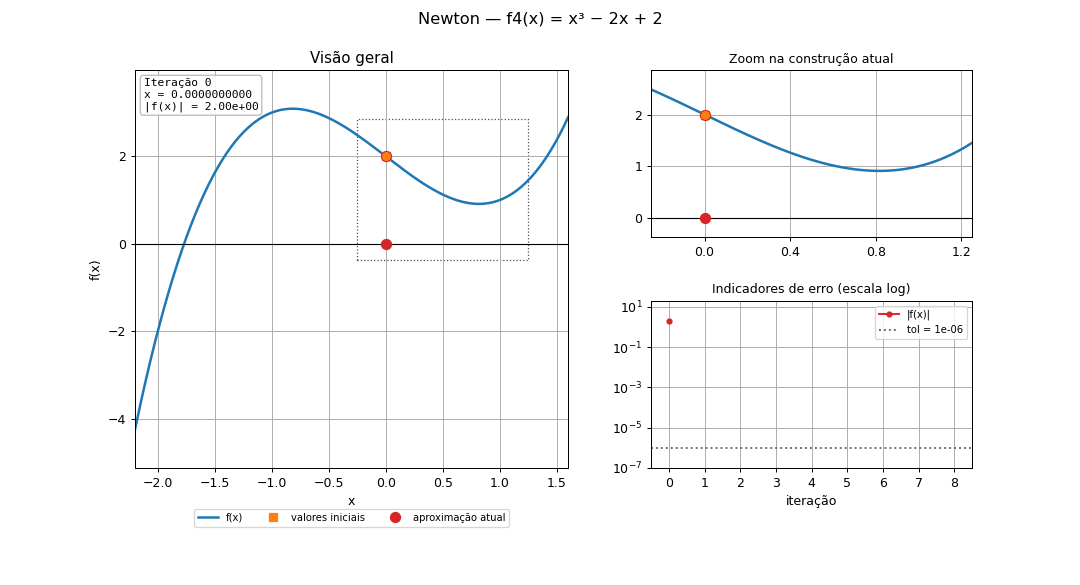

In [29]:
# Escolha das animações: (resultado do método, caso, nome do arquivo, opções de animar).
# casos[0] = f1, casos[1] = f2, casos[2] = f3, casos[3] = f4 (lista da Parte 2).
f2, f3, f4 = casos[1], casos[2], casos[3]

animacoes = [
    # Bisseção em f2, intervalo [1, 2]
    (bissecao(f2["f"], *f2["bissecao"]), f2, "bissecao_f2.gif", {"fps": 2}),
    # Newton em f4, x0 = −2
    (newton(f4["f"], f4["df"], f4["newton"]), f4, "newton_f4.gif", {}),
    # Secante em f3, (x0, x1) = (0, 1)
    (secante(f3["f"], *f3["secante"]), f3, "secante_f3.gif", {}),
    # Caso de falha: Newton em f4 com x0 = 0 (ciclo 0 → 1 → 0 ...)
    (newton(f4["f"], f4["df"], 0), f4, "newton_f4_falha_x0_0.gif",
     {"xlim": (-2.2, 1.6), "max_quadros": 8}),
]

arquivos_gif = []
for r, caso, nome_arquivo, opcoes in animacoes:
    caminho = animar(r, caso["f"], caso["nome"], os.path.join(PASTA_GIFS, nome_arquivo), **opcoes)
    if caminho:
        arquivos_gif.append(caminho)
        print(f"{caminho}: {r['metodo']}, {r['iteracoes']} iterações — {r['mensagem']}")
        display(Image(filename=caminho))

In [30]:
def salvar_tabela_png(tabela_formatada, arquivo):
    """Salva a tabela de resultados como imagem (para colar no dashboard)."""
    n_linhas = len(tabela_formatada)
    fig, ax = plt.subplots(figsize=(11, 0.28 * (n_linhas + 1)), dpi=150)
    ax.axis("off")
    t = ax.table(cellText=tabela_formatada.values, colLabels=tabela_formatada.columns,
                 loc="center", cellLoc="center")
    t.auto_set_font_size(False)
    t.set_fontsize(9)
    t.auto_set_column_width(list(range(len(tabela_formatada.columns))))
    t.scale(1, 1.4)
    for (lin, col), celula in t.get_celld().items():
        if lin == 0:
            celula.set_facecolor("#dbe8f3")
            celula.set_text_props(weight="bold")
    fig.savefig(arquivo, bbox_inches="tight")
    plt.close(fig)


tabela_formatada = formatar_tabela(tabela)
tabela_formatada.to_csv("tabela_resultados.csv", index=False)   # dados da tabela
salvar_tabela_png(tabela_formatada, "tabela_resultados.png")     # imagem da tabela

# Compacta GIFs e tabela em um único arquivo para baixar
import zipfile
with zipfile.ZipFile("entrega_parte3.zip", "w") as z:
    for caminho in arquivos_gif + ["tabela_resultados.csv", "tabela_resultados.png"]:
        z.write(caminho)

try:
    from google.colab import files   # só existe no Colab
    files.download("entrega_parte3.zip")
except ImportError:
    print("Fora do Colab: o arquivo entrega_parte3.zip foi salvo na pasta atual.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>